**Problem Statement:**
Customers’ leaving credit cards services would lead bank to loss, so the bank wants to analyse the data of customers and identify the customers who will leave their credit card services and reason for same – so that bank could improve upon those areas.

As a Data Analyst at Harbor Trust bank, we need to analyse what kind of customers have opted out of service and in the past and prevent customers from opting out from the services.

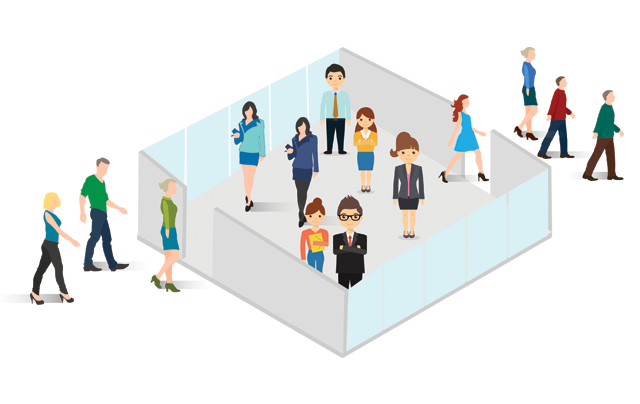

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
bank=pd.read_csv('/content/drive/MyDrive/BankChurners.csv')
bank

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [ ]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

By Observing above columns there are some key variables:

###• **Attrition_Flag:** Target variable indicating if customer attrited ("Attrited Customer") or remained ("Existing Customer")

### • **Demographic variables:** Customer_Age, Gender, Dependent_count, Education_Level, Marital_Status

### • **Financial variables**: Income_Category, Card_Category, Credit_Limit, Total_Revolving_Bal

### • **Behavioral variables**: Months_on_book, Total_Relationship_Count, Months_Inactive_12_mon, Contacts_Count_12_mon

### • **Transaction variables**: Total_Trans_Amt, Total_Trans_Ct, Avg_Utilization_Ratio

In [ ]:
# Count and percentage of customers by churn status
V = bank.pivot_table(index='Attrition_Flag', values='CLIENTNUM', aggfunc='count')
V.rename(columns={'CLIENTNUM': 'Customer_Count'}, inplace=True)
V['Percentage'] = (V['Customer_Count'] / V['Customer_Count'].sum()) * 100
V

,Customer_Count,Percentage
Attrition_Flag,,
Attrited Customer,1627,16.065962
Existing Customer,8500,83.934038


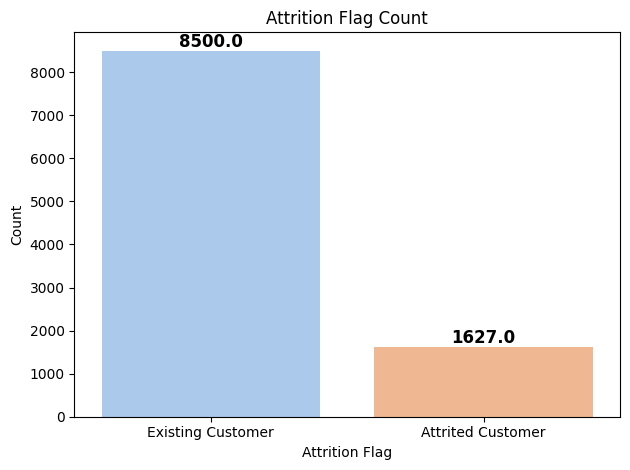

In [ ]:
ax = sns.countplot(x=bank['Attrition_Flag'], palette='pastel')
# Add labels above each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),  # on top of the bar
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')

plt.title('Attrition Flag Count')
plt.xlabel('Attrition Flag')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Observation:** majority are existing customer with the 84% and attrited customer with only 16%.By these we can say that only minority customer opted out for credit card service.

**2.Demographic Variables:**

Analysis on Gender column:

In [ ]:
V1= bank.pivot_table(index='Gender', values='CLIENTNUM', aggfunc='count')
V1.rename(columns={'CLIENTNUM': 'gender_Count'}, inplace=True)
V1['Percentage'] = (V1['gender_Count'] / V1['gender_Count'].sum()) * 100
V1

,gender_Count,Percentage
Gender,,
F,5358,52.908068
M,4769,47.091932


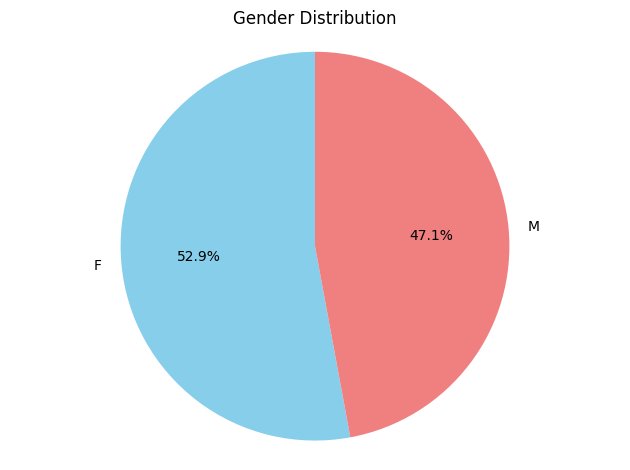

In [ ]:
gender_counts = bank['Gender'].value_counts()
gender_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'],ylabel='', startangle=90)
plt.axis('equal')
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()


In [ ]:


vv = bank.groupby('Attrition_Flag')['Gender'].value_counts()
total_count = vv.sum()
percentage = vv / total_count * 100
result = pd.DataFrame({
    'Gender Count': vv,
    'Percentage': percentage
})
result = result.reset_index()
result

,Attrition_Flag,Gender,Gender Count,Percentage
0,Attrited Customer,F,930,9.183371
1,Attrited Customer,M,697,6.882591
2,Existing Customer,F,4428,43.724696
3,Existing Customer,M,4072,40.209341


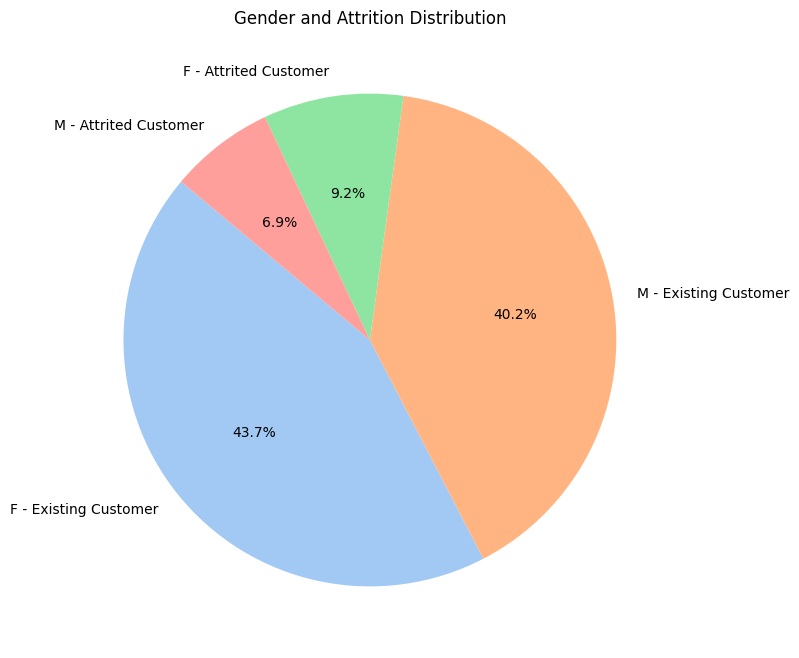

In [ ]:

# Create a combined column
bank['Gender_Attrition'] = bank['Gender'] + ' - ' + bank['Attrition_Flag']

# Count combinations
combined_counts = bank['Gender_Attrition'].value_counts()

# Plot
plt.figure(figsize=(8, 8))
plt.pie(combined_counts,
        labels=combined_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))
plt.title('Gender and Attrition Distribution')
plt.show()


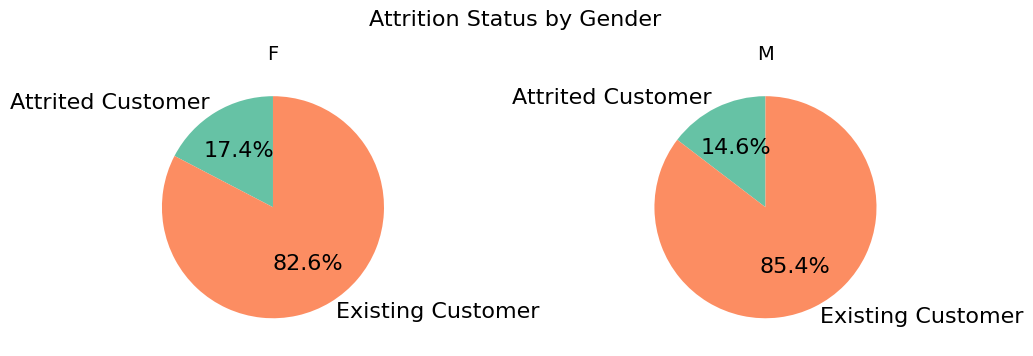

In [ ]:



import matplotlib.pyplot as plt

# Group the data
gender_attrition = bank.groupby(['Gender', 'Attrition_Flag']).size().unstack()

# Plot pie charts side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

colors = ['#66c2a5', '#fc8d62']  # Custom pastel colors

for i, gender in enumerate(gender_attrition.index):
    axes[i].pie(gender_attrition.loc[gender],
                labels=gender_attrition.columns,
                autopct='%1.1f%%',
                startangle=90,
                colors=colors,
                textprops={'fontsize': 16})
    axes[i].set_title(f'{gender}', fontsize=14)

plt.suptitle('Attrition Status by Gender', fontsize=16,y=0.8)
plt.tight_layout()
plt.show()


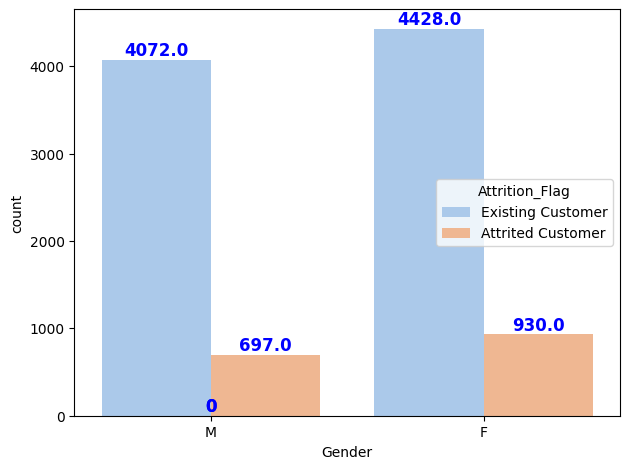

In [ ]:

a=sns.countplot(x='Gender',data=bank,palette='pastel',hue='Attrition_Flag')
for p in a.patches:
    height = p.get_height()
    a.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='b')
plt.tight_layout()
plt.show()

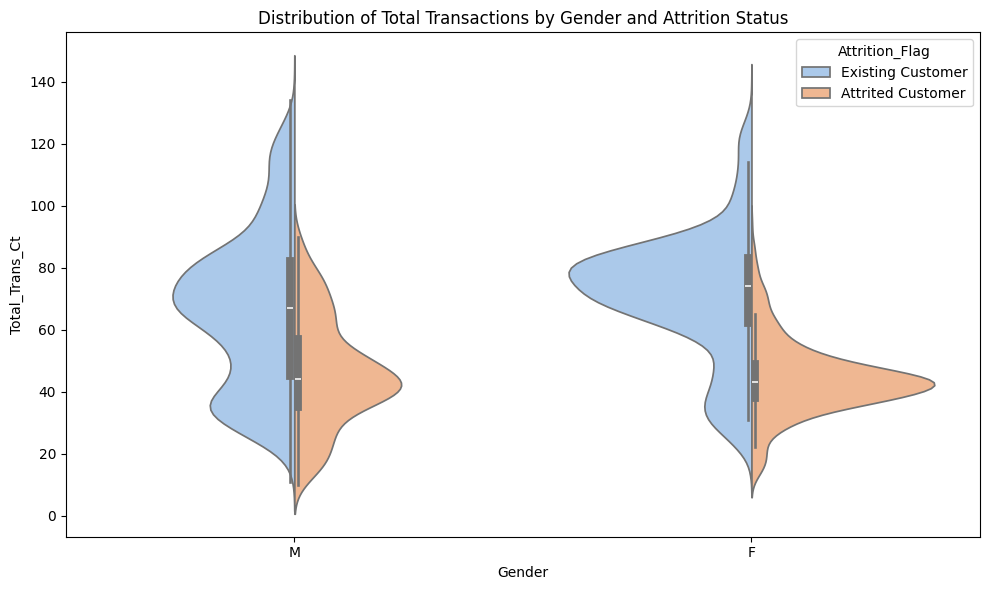

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(x='Gender', y='Total_Trans_Ct', hue='Attrition_Flag', data=bank, palette='pastel', split=True)

plt.title('Distribution of Total Transactions by Gender and Attrition Status')
plt.tight_layout()
plt.show()


**Observation:**

1. Roughly equal distribution between male and female,female has just 5% more count than male.
2.According to the count of male amd female the attrition rate has minimal diffrence between them.



Analysis on Dependent_Count column:

In [ ]:
V2= bank.pivot_table(index='Dependent_count', values='CLIENTNUM', aggfunc='count')
V2.rename(columns={'CLIENTNUM': 'dependent_Count'}, inplace=True)
V2['Percentage'] = (V2['dependent_Count'] / V2['dependent_Count'].sum()) * 100
V2

,dependent_Count,Percentage
Dependent_count,,
0,904,8.926632
1,1838,18.149501
2,2655,26.217044
3,2732,26.977387
4,1574,15.542609
5,424,4.186827


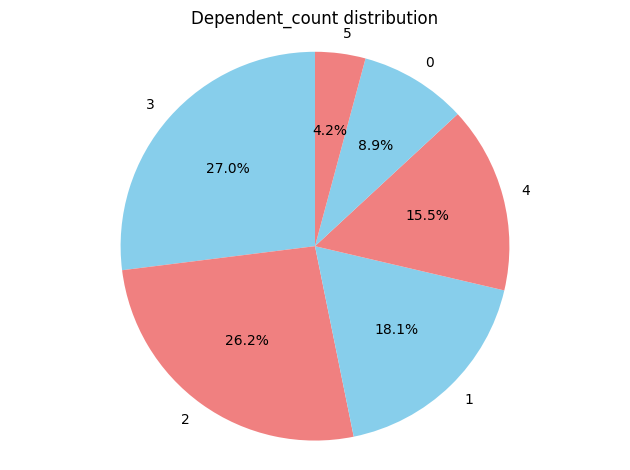

In [ ]:
gender_counts = bank['Dependent_count'].value_counts()
gender_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'],ylabel='', startangle=90)
plt.axis('equal')
plt.title('Dependent_count distribution')
plt.tight_layout()
plt.show()


In [ ]:

vv1 = bank.groupby('Dependent_count')['Attrition_Flag'].value_counts()
total_count = vv1.sum()
percentage = vv1 / total_count * 100
result = pd.DataFrame({
    'dependent_count Count': vv1,
    'Percentage': percentage
})
result = result.reset_index()
result

,Dependent_count,Attrition_Flag,dependent_count Count,Percentage
0,0,Existing Customer,769,7.593562
1,0,Attrited Customer,135,1.333070
2,1,Existing Customer,1569,15.493236
3,1,Attrited Customer,269,2.656265
4,2,Existing Customer,2238,22.099338
5,2,Attrited Customer,417,4.117705
6,3,Existing Customer,2250,22.217834
7,3,Attrited Customer,482,4.759554
8,4,Existing Customer,1314,12.975215
9,4,Attrited Customer,260,2.567394


In [ ]:
grouped = bank.groupby(['Dependent_count', 'Attrition_Flag']).size().reset_index(name='Count')

grouped['Percentage'] = grouped['Count'] / grouped.groupby('Dependent_count')['Count'].transform('sum') * 100

grouped

,Dependent_count,Attrition_Flag,Count,Percentage
0,0,Attrited Customer,135,14.933628
1,0,Existing Customer,769,85.066372
2,1,Attrited Customer,269,14.635473
3,1,Existing Customer,1569,85.364527
4,2,Attrited Customer,417,15.706215
5,2,Existing Customer,2238,84.293785
6,3,Attrited Customer,482,17.642753
7,3,Existing Customer,2250,82.357247
8,4,Attrited Customer,260,16.518424
9,4,Existing Customer,1314,83.481576


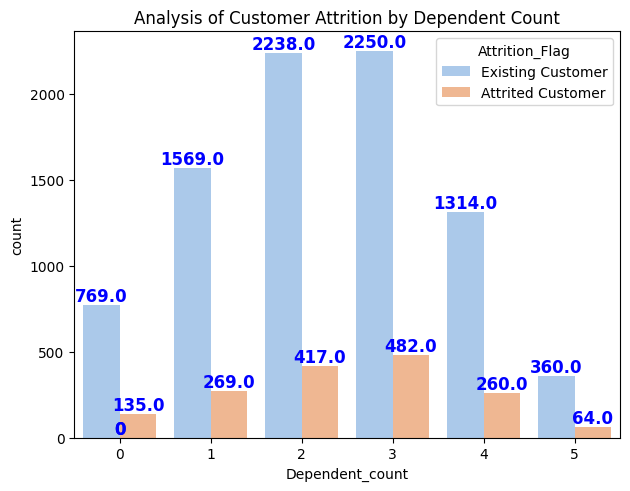

In [ ]:
a=sns.countplot(x='Dependent_count',data=bank,palette='pastel',hue='Attrition_Flag')
for p in a.patches:
    height = p.get_height()
    a.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='b')
plt.tight_layout()
plt.title('Analysis of Customer Attrition by Dependent Count')
plt.show()

**Observation:**

Customers with 3 and 2 dependents churn more —possibly due to financial strain.

**Reccomendation:**

1.Flexible Payment Plans

2.Financial Assistance/Discounts

3.Value Proposition Enhancement







Analysis on Customer_Age column:

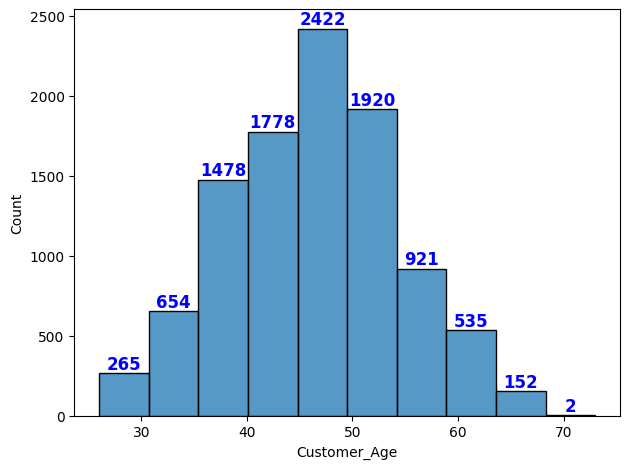

In [ ]:

a3=sns.histplot(x='Customer_Age',data=bank,bins=10,palette='pastel')
for p in a3.patches:
    height = p.get_height()
    a3.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='b')
plt.tight_layout()
plt.show()

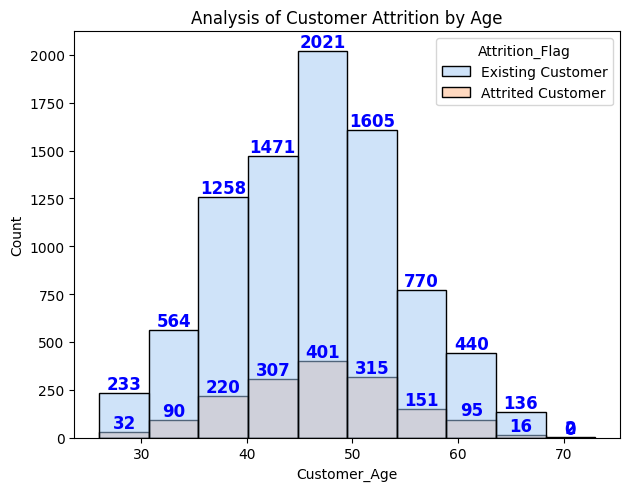

In [ ]:
a2=sns.histplot(x='Customer_Age',data=bank,bins=10,palette='pastel',hue='Attrition_Flag')
for p in a2.patches:
    height = p.get_height()
    a2.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='b')
plt.tight_layout()
plt.title('Analysis of Customer Attrition by Age')
plt.show()

**Observation:**

*  Majority customers  between 40 to 60 age group.
*  Most churn rate between 40 to 60 age group.



Analysis on Education_Level column:

In [ ]:
V3= bank.pivot_table(index='Education_Level', values='CLIENTNUM', aggfunc='count')
V3.rename(columns={'CLIENTNUM': 'Education_Level_Count'}, inplace=True)
V3['Percentage'] = (V3['Education_Level_Count'] / V3['Education_Level_Count'].sum()) * 100
V3

,Education_Level_Count,Percentage
Education_Level,,
College,1013,10.002962
Doctorate,451,4.453441
Graduate,3128,30.887726
High School,2013,19.877555
Post-Graduate,516,5.095290
Uneducated,1487,14.683519
Unknown,1519,14.999506


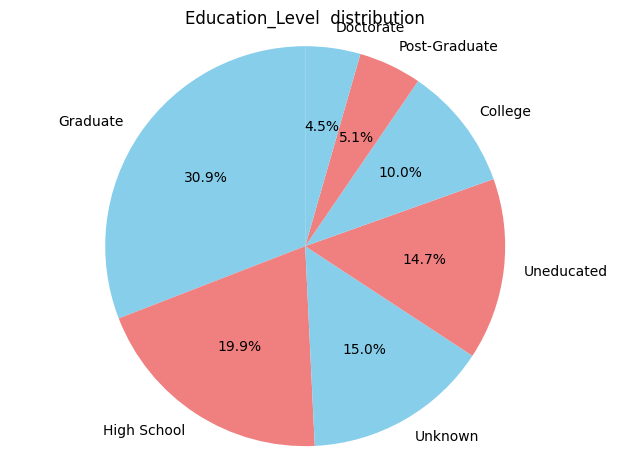

In [ ]:
gender_counts = bank['Education_Level'].value_counts()
gender_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'],ylabel='', startangle=90)
plt.axis('equal')
plt.title('Education_Level  distribution')
plt.tight_layout()
plt.show()

In [ ]:
vv2 = bank.groupby('Education_Level')['Attrition_Flag'].value_counts()
total_count = vv2.sum()
percentage = vv2 / total_count * 100
result = pd.DataFrame({
    'Education_level Count': vv2,
    'Percentage': percentage
})
result = result.reset_index()
result

,Education_Level,Attrition_Flag,Education_level Count,Percentage
0,College,Existing Customer,859,8.482275
1,College,Attrited Customer,154,1.520687
2,Doctorate,Existing Customer,356,3.515355
3,Doctorate,Attrited Customer,95,0.938086
4,Graduate,Existing Customer,2641,26.078799
5,Graduate,Attrited Customer,487,4.808927
6,High School,Existing Customer,1707,16.855930
7,High School,Attrited Customer,306,3.021625
8,Post-Graduate,Existing Customer,424,4.186827
9,Post-Graduate,Attrited Customer,92,0.908463


In [ ]:
grouped = bank.groupby(['Education_Level', 'Attrition_Flag']).size().reset_index(name='Count')

# Use transform instead of apply to keep index aligned
grouped['Percentage'] = grouped['Count'] / grouped.groupby('Education_Level')['Count'].transform('sum') * 100

grouped

,Education_Level,Attrition_Flag,Count,Percentage
0,College,Attrited Customer,154,15.202369
1,College,Existing Customer,859,84.797631
2,Doctorate,Attrited Customer,95,21.064302
3,Doctorate,Existing Customer,356,78.935698
4,Graduate,Attrited Customer,487,15.569054
5,Graduate,Existing Customer,2641,84.430946
6,High School,Attrited Customer,306,15.201192
7,High School,Existing Customer,1707,84.798808
8,Post-Graduate,Attrited Customer,92,17.829457
9,Post-Graduate,Existing Customer,424,82.170543


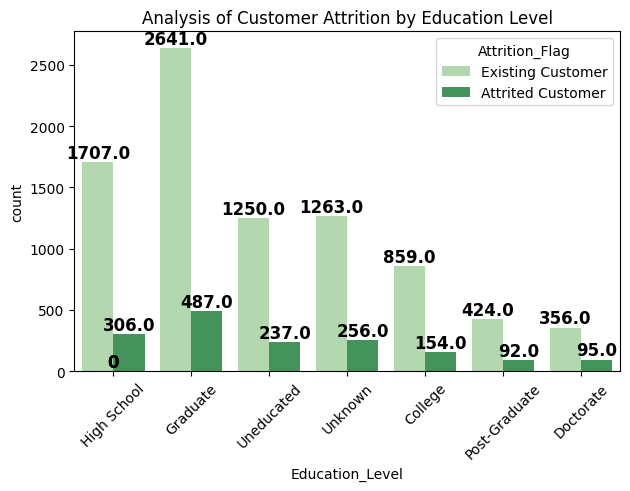

In [ ]:
a2=sns.countplot(x='Education_Level',data=bank,palette='Greens',hue='Attrition_Flag')
for p in a2.patches:
    height = p.get_height()
    a2.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='k')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Analysis of Customer Attrition by Education Level')
plt.show()

**Observation:**
 1. Most Educated Customers (Doctorate) Have Highest Attrition
Attrition Rate: 21.06%

Could suggest dissatisfaction or greater market awareness/options.

2. College, High School, Graduate = Most Retained
All have attrition rates around 15.2%, with ~85% retention.

This suggests these education levels have a strong, stable relationship with the bank.

3. Unknown/Uneducated Slightly Less Stable
Attrition rates are 16.85% (Unknown) and 15.94% (Uneducated).

Still not alarming, but higher than average.

Analysis on Marital_Status column:

In [ ]:
V4= bank.pivot_table(index='Marital_Status', values='CLIENTNUM', aggfunc='count')
V4.rename(columns={'CLIENTNUM': 'Marital_Status_Count'}, inplace=True)
V4['Percentage'] = (V4['Marital_Status_Count'] / V4['Marital_Status_Count'].sum()) * 100
V4

,Marital_Status_Count,Percentage
Marital_Status,,
Divorced,748,7.386195
Married,4687,46.282216
Single,3943,38.935519
Unknown,749,7.396070


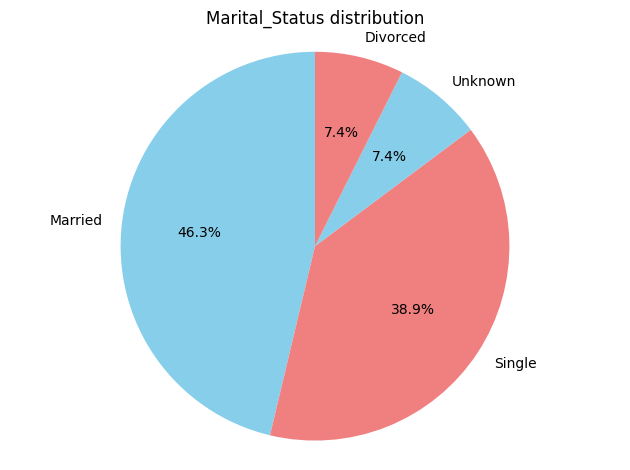

In [ ]:
Marital_Status_counts = bank['Marital_Status'].value_counts()
Marital_Status_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'],ylabel='', startangle=90)
plt.axis('equal')
plt.title('Marital_Status distribution')
plt.tight_layout()
plt.show()

In [ ]:
vv3 = bank.groupby('Marital_Status')['Attrition_Flag'].value_counts()
total_count = vv3.sum()
percentage = vv3/ total_count * 100
result = pd.DataFrame({
    'Marital_Status Count': vv3,
    'Percentage': percentage
})
result = result.reset_index()
result

,Marital_Status,Attrition_Flag,Marital_Status Count,Percentage
0,Divorced,Existing Customer,627,6.191370
1,Divorced,Attrited Customer,121,1.194826
2,Married,Existing Customer,3978,39.281130
3,Married,Attrited Customer,709,7.001086
4,Single,Existing Customer,3275,32.339291
5,Single,Attrited Customer,668,6.596228
6,Unknown,Existing Customer,620,6.122247
7,Unknown,Attrited Customer,129,1.273822


In [ ]:
grouped = bank.groupby(['Marital_Status', 'Attrition_Flag']).size().reset_index(name='Count')
grouped['Percentage'] = grouped['Count'] / grouped.groupby('Marital_Status')['Count'].transform('sum') * 100
grouped

,Marital_Status,Attrition_Flag,Count,Percentage
0,Divorced,Attrited Customer,121,16.176471
1,Divorced,Existing Customer,627,83.823529
2,Married,Attrited Customer,709,15.126947
3,Married,Existing Customer,3978,84.873053
4,Single,Attrited Customer,668,16.941415
5,Single,Existing Customer,3275,83.058585
6,Unknown,Attrited Customer,129,17.222964
7,Unknown,Existing Customer,620,82.777036


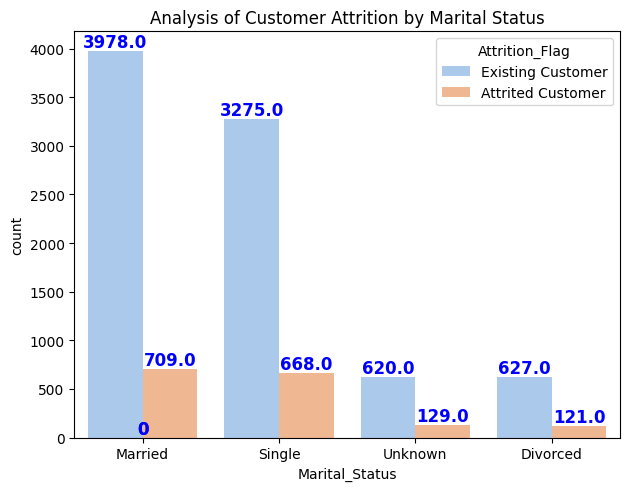

In [ ]:
a3=sns.countplot(x='Marital_Status',data=bank,palette='pastel',hue='Attrition_Flag')
for p in a3.patches:
  height = p.get_height()
  a3.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='b')
plt.tight_layout()
plt.title('Analysis of Customer Attrition by Marital Status')
plt.show()

**Obseravtion:**
 1. Married Customers = Most Loyal
Lowest attrition rate (15.13%)

 Highest total customers (4687)

 Stable relationship likely correlates with financial stability

 2. Unknown Marital Status = Highest Attrition (17.22%)
May indicate customers who are either new, less engaged.

 3. Singles and Divorced = Slightly Higher Risk
Attrition ~16–17%

 May represent more transitional life stages or different financial needs



**3.Financial Variables:**

Analysis on Income_Category column:

In [ ]:
V4= bank.pivot_table(index='Income_Category', values='CLIENTNUM', aggfunc='count')
V4.rename(columns={'CLIENTNUM': 'Income_Category_Count'}, inplace=True)
V4['Percentage'] = (V4['Income_Category_Count'] / V4['Income_Category_Count'].sum()) * 100
V4

,Income_Category_Count,Percentage
Income_Category,,
$120K +,727,7.178829
$40K - $60K,1790,17.675521
$60K - $80K,1402,13.844179
$80K - $120K,1535,15.157500
Less than $40K,3561,35.163425
Unknown,1112,10.980547


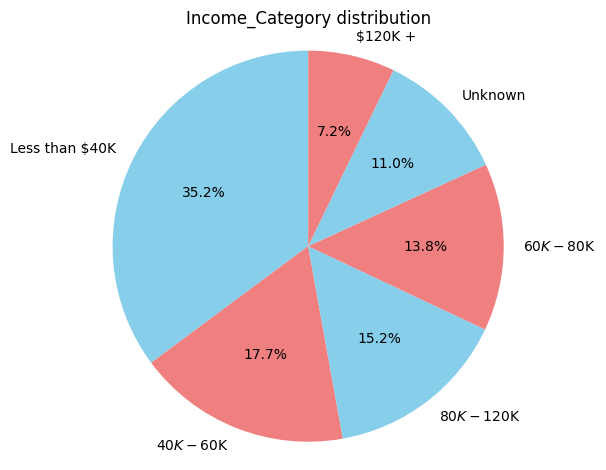

In [ ]:
Income_Category_counts = bank['Income_Category'].value_counts()
Income_Category_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'],ylabel='', startangle=90)
plt.axis('equal')
plt.title('Income_Category distribution')
plt.tight_layout()
plt.show()

In [ ]:
grouped = bank.groupby(['Income_Category', 'Attrition_Flag']).size().reset_index(name='Count')
grouped['Percentage'] = grouped['Count'] / grouped.groupby('Income_Category')['Count'].transform('sum') * 100
grouped


,Income_Category,Attrition_Flag,Count,Percentage
0,$120K +,Attrited Customer,126,17.331499
1,$120K +,Existing Customer,601,82.668501
2,$40K - $60K,Attrited Customer,271,15.139665
3,$40K - $60K,Existing Customer,1519,84.860335
4,$60K - $80K,Attrited Customer,189,13.480742
5,$60K - $80K,Existing Customer,1213,86.519258
6,$80K - $120K,Attrited Customer,242,15.765472
7,$80K - $120K,Existing Customer,1293,84.234528
8,Less than $40K,Attrited Customer,612,17.186184
9,Less than $40K,Existing Customer,2949,82.813816


In [ ]:
vv4 = bank.groupby('Income_Category')['Attrition_Flag'].value_counts()
total_count = vv4.sum()
percentage = vv4/ total_count * 100
result = pd.DataFrame({
    'Income_Category_Count': vv4,
    'Percentage': percentage
})
result = result.reset_index()
result

,Income_Category,Attrition_Flag,Income_Category_Count,Percentage
0,$120K +,Existing Customer,601,5.934630
1,$120K +,Attrited Customer,126,1.244199
2,$40K - $60K,Existing Customer,1519,14.999506
3,$40K - $60K,Attrited Customer,271,2.676015
4,$60K - $80K,Existing Customer,1213,11.977881
5,$60K - $80K,Attrited Customer,189,1.866298
6,$80K - $120K,Existing Customer,1293,12.767848
7,$80K - $120K,Attrited Customer,242,2.389651
8,Less than $40K,Existing Customer,2949,29.120174
9,Less than $40K,Attrited Customer,612,6.043251


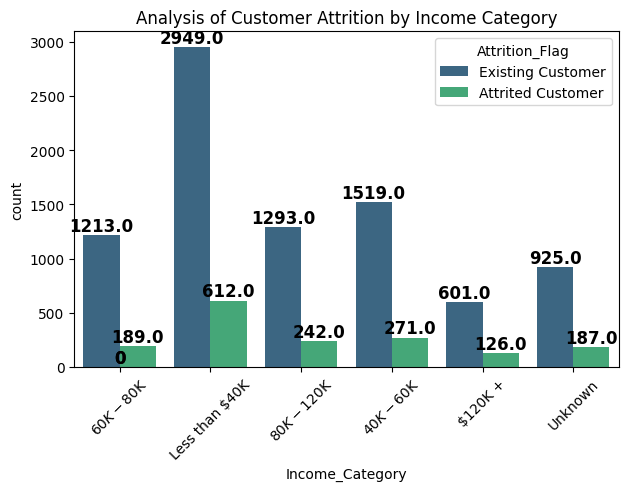

In [ ]:
a4=sns.countplot(x='Income_Category',data=bank,palette='viridis',hue='Attrition_Flag')
for p in a4.patches:
  height = p.get_height()
  a4.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='k')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Analysis of Customer Attrition by Income Category')
plt.show()

**Observation:**


1.Less than $40K - Highest number of customers, but also among the highest attrition rates. Indicates possible dissatisfaction in lower income groups.

2.$120K +	-	Surprisingly high attrition despite higher income — could suggest unmet expectations or better offers elsewhere.

3.$40K - $60K dollars	-	Healthy retention. Mid-income customers appear fairly stable.

4-$60K - $80K dollars	-	One of the best retention segments.

5.$80K - $120K dollars	-	Slightly more attrition than $60K-$80K group, but still  
   strong retention.

6.Unknown	-	Higher attrition than expected. May suggest that lack of income info correlates with disengagement.

Analysis on Card_Category column:

In [ ]:
V5= bank.pivot_table(index='Card_Category', values='CLIENTNUM', aggfunc='count')
V5.rename(columns={'CLIENTNUM': 'Card_Category_Count'}, inplace=True)
V5['Percentage'] = (V5['Card_Category_Count'] / V5['Card_Category_Count'].sum()) * 100
V5

,Card_Category_Count,Percentage
Card_Category,,
Blue,9436,93.176656
Gold,116,1.145453
Platinum,20,0.197492
Silver,555,5.480399


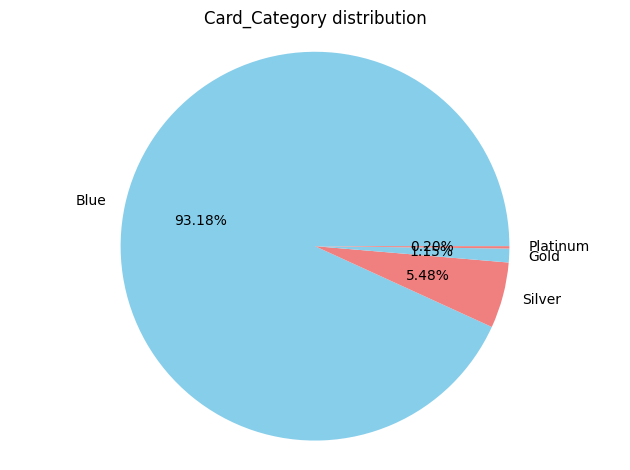

In [ ]:
Card_Category_counts = bank['Card_Category'].value_counts()
Card_Category_counts.plot(kind='pie', autopct='%0.2f%%', colors=['skyblue', 'lightcoral'],ylabel='')
plt.axis('equal')
plt.title('Card_Category distribution')
plt.tight_layout()
plt.show()

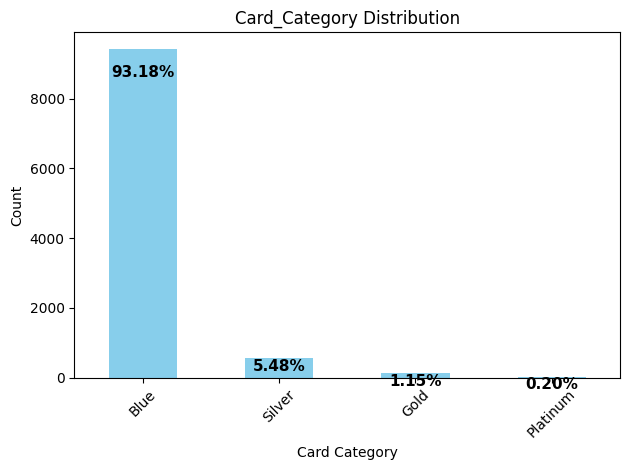

In [ ]:
import matplotlib.pyplot as plt

# Count of Card_Category
Card_Category_counts = bank['Card_Category'].value_counts()

# Bar plot
Card_Category_counts.plot(kind='bar', color='skyblue')

# Annotate each bar with percentage
total = Card_Category_counts.sum()
for i, count in enumerate(Card_Category_counts):
    percent = count / total * 100
    plt.text(i, count - (0.05 * count), f'{percent:.2f}%', ha='center', va='top', fontsize=11, fontweight='bold', color='black')

plt.ylabel('Count')
plt.xlabel('Card Category')
plt.title('Card_Category Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
vv5 = bank.groupby('Card_Category')['Attrition_Flag'].value_counts()
total_count = vv5.sum()
percentage = vv5/ total_count * 100
result = pd.DataFrame({
    'Card_Category_Count': vv5,
    'Percentage': percentage
})
result = result.reset_index()
result

,Card_Category,Attrition_Flag,Card_Category_Count,Percentage
0,Blue,Existing Customer,7917,78.177150
1,Blue,Attrited Customer,1519,14.999506
2,Gold,Existing Customer,95,0.938086
3,Gold,Attrited Customer,21,0.207366
4,Platinum,Existing Customer,15,0.148119
5,Platinum,Attrited Customer,5,0.049373
6,Silver,Existing Customer,473,4.670682
7,Silver,Attrited Customer,82,0.809717


In [ ]:
grouped = bank.groupby(['Card_Category', 'Attrition_Flag']).size().reset_index(name='Count')
grouped['Percentage'] = grouped['Count'] / grouped.groupby('Card_Category')['Count'].transform('sum') * 100
grouped

,Card_Category,Attrition_Flag,Count,Percentage
0,Blue,Attrited Customer,1519,16.097923
1,Blue,Existing Customer,7917,83.902077
2,Gold,Attrited Customer,21,18.103448
3,Gold,Existing Customer,95,81.896552
4,Platinum,Attrited Customer,5,25.000000
5,Platinum,Existing Customer,15,75.000000
6,Silver,Attrited Customer,82,14.774775
7,Silver,Existing Customer,473,85.225225


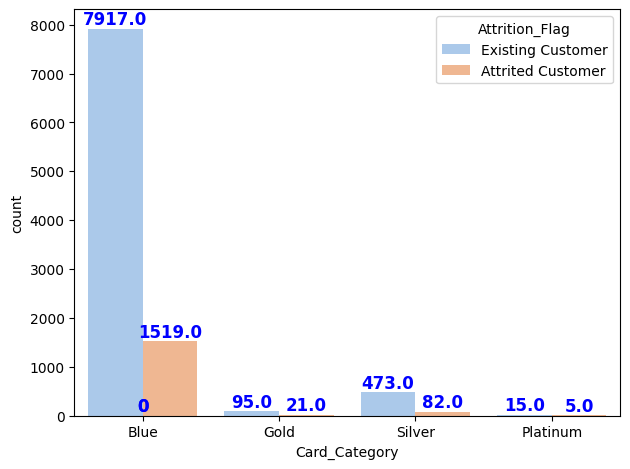

In [ ]:
a5=sns.countplot(x='Card_Category',data=bank,palette='pastel',hue='Attrition_Flag')
for p in a5.patches:
  height = p.get_height()
  a5.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='b')
plt.tight_layout()
plt.show()

**Obseravtion:**

1.**Blue card** dominates in volume; although retention is good, total attrition count is still high due to more size.

2.**Silver card** is a top performer — lowest attrition %, suggesting customer satisfaction.

3.**Gold card** might need value proposition improvements or better communication of benefits.

4.**Platinum card** shows concerning attrition (25%) — though sample size is small, it may indicate issues with exclusivity, fees, or services.



In [ ]:
bank.groupby('Income_Category')['Card_Category'].value_counts()

Income_Category  Card_Category
$120K +          Blue              645
                 Silver             60
                 Gold               18
                 Platinum            4
$40K - $60K      Blue             1675
                 Silver             99
                 Gold               15
                 Platinum            1
$60K - $80K      Blue             1273
                 Silver             96
                 Gold               29
                 Platinum            4
$80K - $120K     Blue             1395
                 Silver            117
                 Gold               21
                 Platinum            2
Less than $40K   Blue             3403
                 Silver            130
                 Gold               24
                 Platinum            4
Unknown          Blue             1045
                 Silver             53
                 Gold                9
                 Platinum            5
Name: count, dtype: int64

Analysis on Credit_Limit column:

In [ ]:
V9= bank.pivot_table(index='Credit_Limit', values='CLIENTNUM', aggfunc='count')
V9.rename(columns={'CLIENTNUM': 'Credit_Limit_Count'}, inplace=True)
V9['Percentage'] = (V9['Credit_Limit_Count'] / V9['Credit_Limit_Count'].sum()) * 100
V9

,Credit_Limit_Count,Percentage
Credit_Limit,,
1438.3,507,5.006418
1439.0,2,0.019749
1440.0,1,0.009875
1441.0,2,0.019749
1442.0,1,0.009875
...,...,...
34198.0,1,0.009875
34427.0,1,0.009875
34458.0,1,0.009875


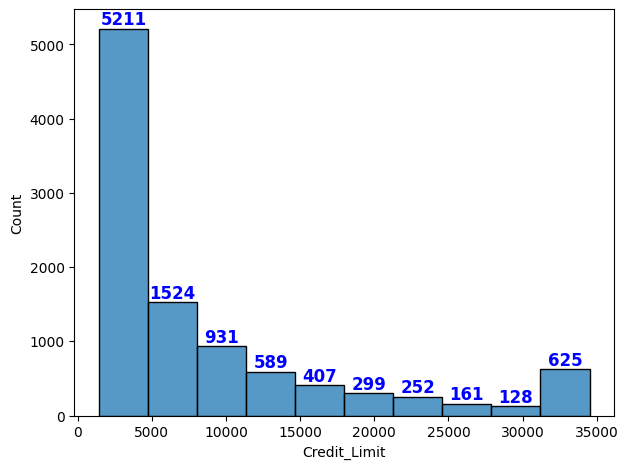

In [ ]:
a5=sns.histplot(x='Credit_Limit',data=bank,bins=10,palette='pastel')
for p in a5.patches:
    height = p.get_height()
    a5.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='b')
plt.tight_layout()
plt.show()

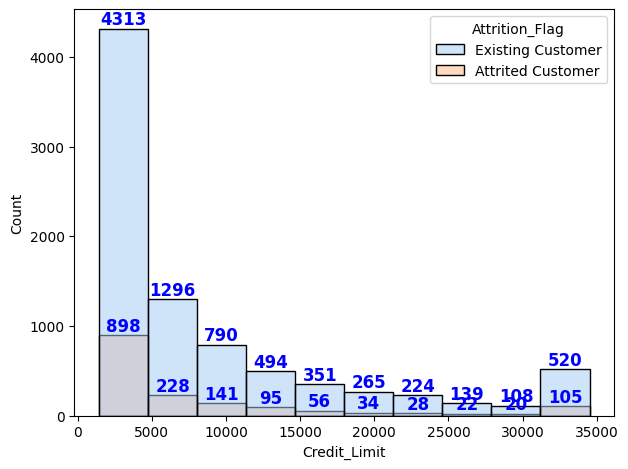

In [ ]:
a4=sns.histplot(x='Credit_Limit',data=bank,bins=10,palette='pastel',hue='Attrition_Flag')
for p in a4.patches:
    height = p.get_height()
    a4.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='b')
plt.tight_layout()
plt.show()

**Obseravtion:**

1.Majority have low credit limits.

2.Attrited customers are more concentrated in lower limits.

3.High credit limits see fewer customers.

4.Balanced retention at higher limits

Analysis on Total_Revolving_Bal column:

In [ ]:
V6= bank.pivot_table(index='Total_Revolving_Bal', values='CLIENTNUM', aggfunc='count')
V6.rename(columns={'CLIENTNUM': 'Total_Revolving_Bal_Count'}, inplace=True)
V6['Percentage'] = (V6['Total_Revolving_Bal_Count'] / V6['Total_Revolving_Bal_Count'].sum()) * 100
V6

,Total_Revolving_Bal_Count,Percentage
Total_Revolving_Bal,,
0,2470,24.390244
132,1,0.009875
134,1,0.009875
145,1,0.009875
154,1,0.009875
...,...,...
2511,1,0.009875
2512,2,0.019749
2513,1,0.009875


In [ ]:
t1 = bank.pivot_table(index='Attrition_Flag', values='Total_Revolving_Bal', aggfunc=('mean','count','sum','median'))
t1

,count,mean,median,sum
Attrition_Flag,,,,
Attrited Customer,1627,672.822987,0.0,1094683
Existing Customer,8500,1256.604118,1364.0,10681135


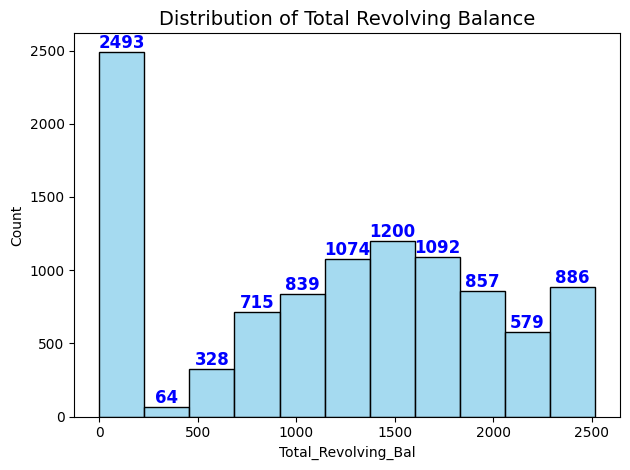

In [ ]:
a6 = sns.histplot(x='Total_Revolving_Bal', data=bank, bins=11, color='skyblue')
for p in a6.patches:
    height = p.get_height()
    a6.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='blue')

plt.title("Distribution of Total Revolving Balance", fontsize=14)
plt.tight_layout()
plt.show()


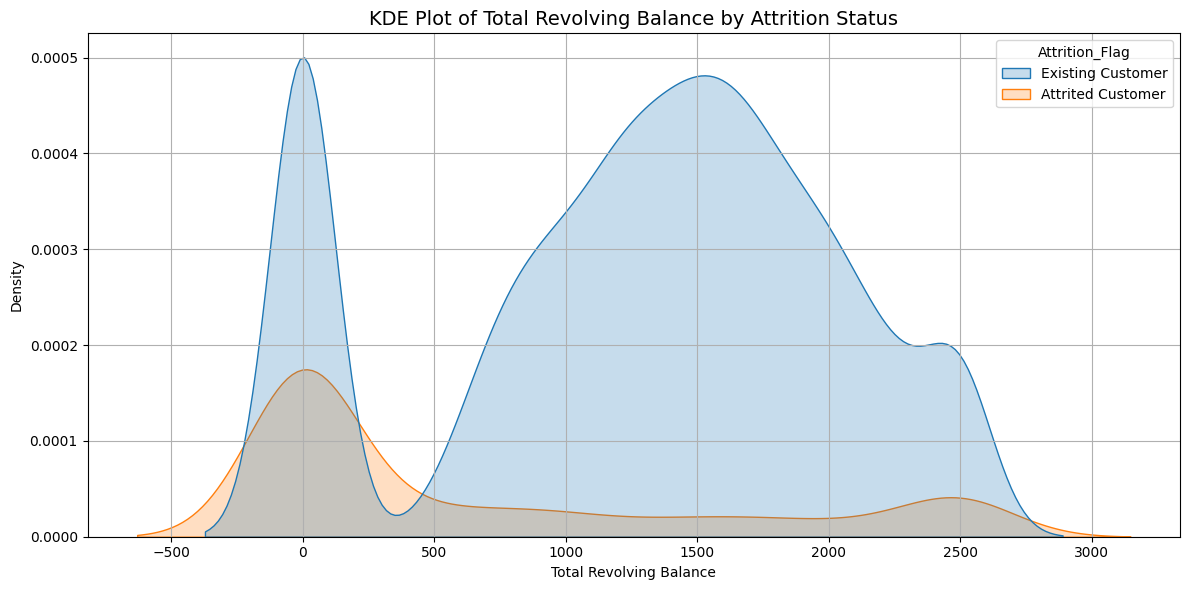

In [ ]:
plt.figure(figsize=(3, 3))
sns.kdeplot(data=bank, x='Total_Revolving_Bal', hue='Attrition_Flag', fill=True)
plt.title('KDE Plot of Total Revolving Balance by Attrition Status', fontsize=14)
plt.xlabel('Total Revolving Balance')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

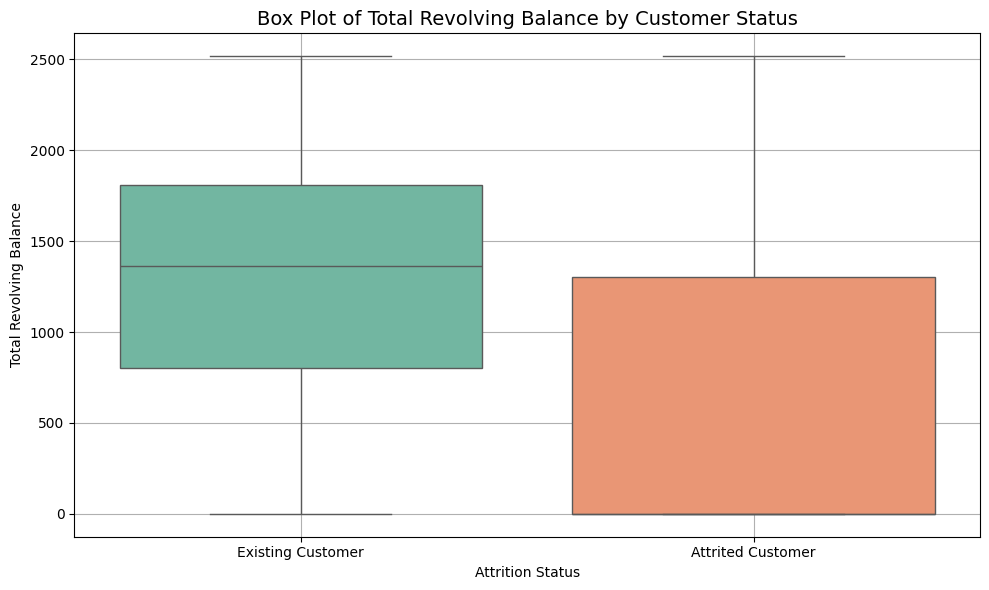

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=bank, x='Attrition_Flag', y='Total_Revolving_Bal', palette='Set2')

plt.title('Box Plot of Total Revolving Balance by Customer Status', fontsize=14)
plt.xlabel('Attrition Status')
plt.ylabel('Total Revolving Balance')
plt.grid(True)
plt.tight_layout()
plt.show()


**Observation:**

*Attrited customers mostly have low or zero revolving balances.

*Existing customers show a wider range, especially between 1000–2000.

*High revolving balances are more common among retained customers.

*Low balance may indicate inactivity and potential churn.

**Behavioural Analysis:**

Analysis on Months_Inactive_12_mon column:

In [ ]:
ba1=bank.pivot_table(index='Attrition_Flag',values='Months_Inactive_12_mon',aggfunc=['mean'])
ba1

,mean
,Months_Inactive_12_mon
Attrition_Flag,
Attrited Customer,2.693301
Existing Customer,2.273765


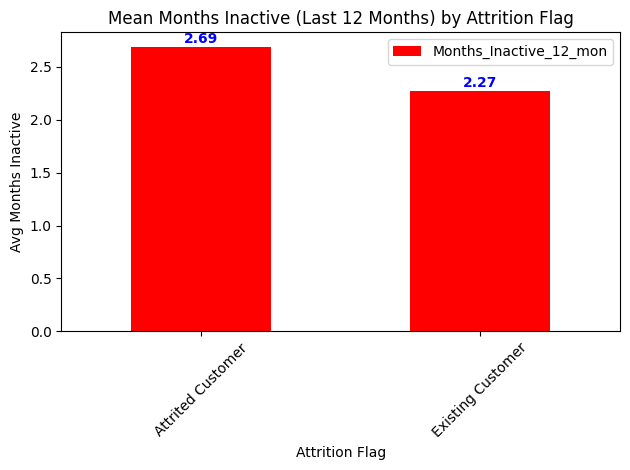

In [ ]:
ba1 = bank.pivot_table(index='Attrition_Flag', values='Months_Inactive_12_mon', aggfunc='mean')
bars=ba1.plot(kind='bar', color='r')
for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='blue')
plt.xticks(rotation=45)
plt.title("Mean Months Inactive (Last 12 Months) by Attrition Flag")
plt.xlabel("Attrition Flag")
plt.ylabel("Avg Months Inactive")
plt.tight_layout()
plt.show()

**Observation:**

*Attrited customers were inactive for a longer average duration (2.69 months).

*Existing customers showed slightly better engagement (2.27 months inactive).

*Higher inactivity correlates with a greater likelihood of churn.

*Proactive engagement could help reduce customer attrition.

Analysis on Months_Inactive_12_mon column:

In [ ]:
bb=bank.pivot_table(index='Attrition_Flag',values='Contacts_Count_12_mon',aggfunc='mean')
bb

,Contacts_Count_12_mon
Attrition_Flag,
Attrited Customer,2.972342
Existing Customer,2.356353


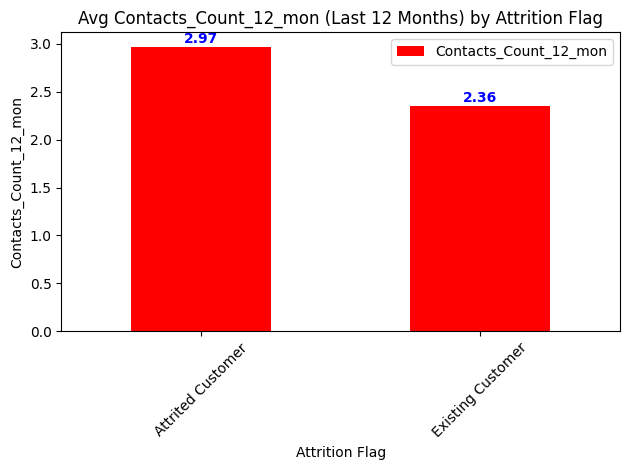

In [ ]:
ba2= bank.pivot_table(index='Attrition_Flag', values='Contacts_Count_12_mon', aggfunc='mean')
barr=ba2.plot(kind='bar', color='r')
for bar in barr.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='blue')
plt.xticks(rotation=45)
plt.title("Avg Contacts_Count_12_mon (Last 12 Months) by Attrition Flag")
plt.xlabel("Attrition Flag")
plt.ylabel("Contacts_Count_12_mon")
plt.tight_layout()
plt.show()

**Observation:**

*Attrited customers contacted the bank more frequently (2.97 times/year).

*Existing customers reached out less (2.36 times/year).

*Higher contact frequency may indicate unresolved issues or dissatisfaction.



Analysis on Total_Relationship_Count column:

In [ ]:
bb1=bank.pivot_table(index='Attrition_Flag',values='Total_Relationship_Count',aggfunc='mean')
bb1

,Total_Relationship_Count
Attrition_Flag,
Attrited Customer,3.279656
Existing Customer,3.914588


<Figure size 800x500 with 0 Axes>

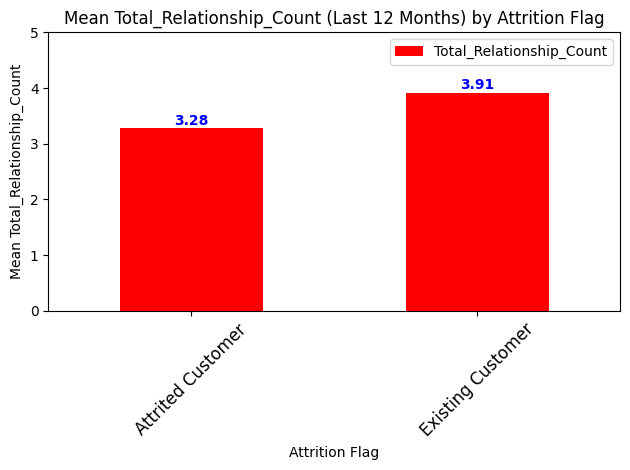

In [ ]:
bb1= bank.pivot_table(index='Attrition_Flag', values='Total_Relationship_Count', aggfunc='mean')
plt.figure(figsize=(8,5))
barr1=bb1.plot(kind='bar', color='r')
for bar in barr1.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='blue')
plt.ylim(0,5.0)
plt.title("Mean Total_Relationship_Count (Last 12 Months) by Attrition Flag")
plt.xlabel("Attrition Flag")
plt.ylabel("Mean Total_Relationship_Count")
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()

**Observation:**

*Existing customers have a higher average relationship count (3.91) than
 attrited ones (3.28).

*Stronger engagement appears to correlate with customer retention.


Analysis on Months_on_book column:




<Axes: xlabel='Months_on_book', ylabel='CLIENTNUM'>

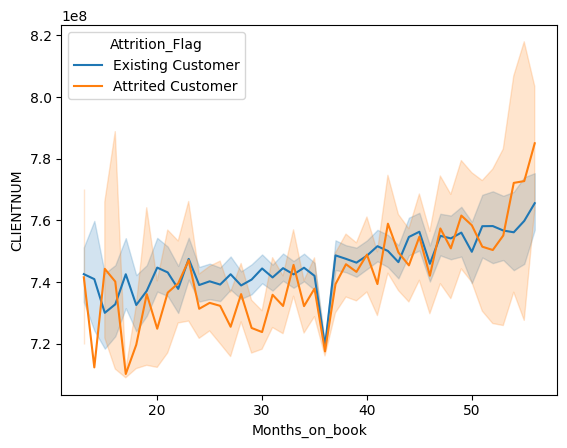

In [ ]:
bb2=bank.pivot_table(index='Attrition_Flag',values='Months_on_book',aggfunc='median')
bb2
sns.lineplot(x=bank['Months_on_book'],y=bank['CLIENTNUM'],data=bank,color='r',hue='Attrition_Flag')

**Obseravation:**

1.Attrited customers generally show lower value in early months (10-35) but
 higher value after month 40.

2.Both customer segments experience a significant dip around month 35.

3.After month 40, both segments trend upward, with attrited customers showing a steeper increase.


# **Transction Variables:**

Analysis on Total_Trans_Amt column:

In [ ]:
V = bank.pivot_table(index='Attrition_Flag', values='Total_Trans_Amt', aggfunc=('mean','count','sum'))
#V.rename(columns={'CLIENTNUM': 'Customer_Count'}, inplace=True)
#V['Percentage'] = (V['Customer_Count'] / V['Customer_Count'].sum()) * 100
V

,count,mean,sum
Attrition_Flag,,,
Attrited Customer,1627,3095.025814,5035607
Existing Customer,8500,4654.655882,39564575


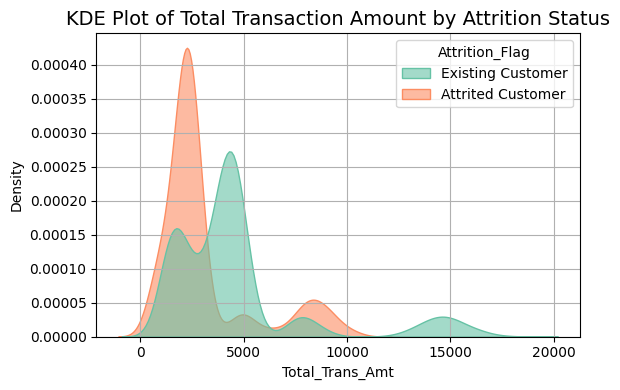

In [ ]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=bank, x='Total_Trans_Amt', hue='Attrition_Flag', fill=True, common_norm=False, palette='Set2', alpha=0.6)
plt.title('KDE Plot of Total Transaction Amount by Attrition Status', fontsize=14)
plt.xlabel('Total_Trans_Amt')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

**Analysis:**

1.Existing customers generally have a higher total transaction amount than attrited customers.

2.The density peak for attrited customers is around 2500–3000, indicating lower spending.

3.Existing customers show multiple peaks at higher transaction amounts, suggesting active engagement.

4.Attrited customers rarely show high transaction amounts, hinting at reduced usage before attrition.

**Recommendation:**
Implement targeted retention strategies for low-spending customers by offering incentives or personalized engagement to boost their transaction activity before they churn.

Analysis on Total_Trans_ct column:

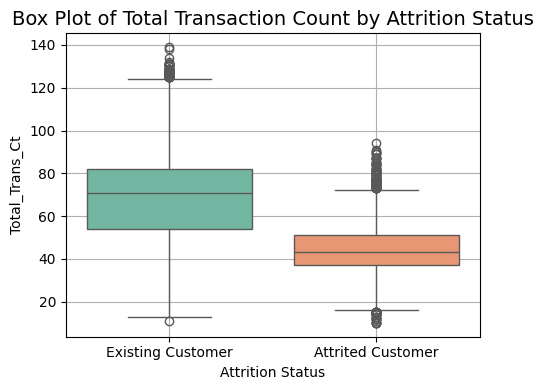

In [ ]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=bank, x='Attrition_Flag', y='Total_Trans_Ct', palette='Set2')
plt.title('Box Plot of Total Transaction Count by Attrition Status', fontsize=14)
plt.xlabel('Attrition Status')
plt.ylabel('Total_Trans_Ct')
plt.grid(True)
plt.tight_layout()
plt.show()


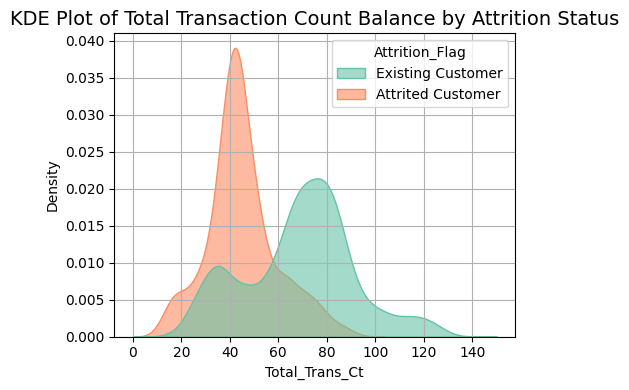

In [ ]:
plt.figure(figsize=(5, 4))
sns.kdeplot(data=bank, x='Total_Trans_Ct', hue='Attrition_Flag', fill=True, common_norm=False, palette='Set2', alpha=0.6)
plt.title('KDE Plot of Total Transaction Count Balance by Attrition Status', fontsize=14)
plt.xlabel('Total_Trans_Ct')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

**Analysis :**

1.Existing customers tend to have a higher number of transactions (Total_Trans_Ct) than attrited customers.

2.The peak for attrited customers occurs around 40 transactions, while for existing customers it peaks around 75.

3.The distribution for existing customers is broader and shifts right, indicating more frequent usage.

4.Attrited customers rarely make more than 60 transactions, suggesting lower engagement levels.

**Recommendation:**
Monitor customers with declining transaction counts and proactively re-engage them through loyalty programs, personalized offers, or usage-based rewards to reduce attrition risk.

Text(0, 0.5, 'Total Transaction Amount')

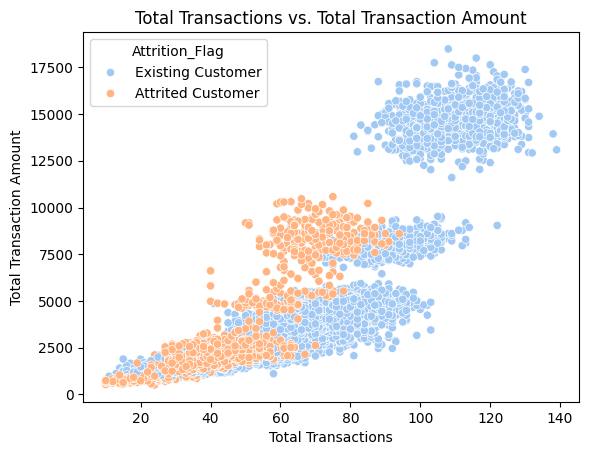

In [ ]:
sns.scatterplot(x='Total_Trans_Ct', y='Total_Trans_Amt', data=bank,hue='Attrition_Flag', palette='pastel')
plt.title('Total Transactions vs. Total Transaction Amount')
plt.xlabel('Total Transactions')
plt.ylabel('Total Transaction Amount')


1.Existing Customers generally have both higher total transactions and higher transaction amounts, clustering in upper ranges.

2.Attrited Customers are mostly concentrated in lower transaction counts and lower transaction amounts.

3.A clear positive correlation is visible between transaction count and amount for both groups.

4.This suggests that engaged customers with higher transaction activity are more likely to be retained.

 **Recommendation**:
Encourage frequent usage with loyalty programs or cashback offers to reduce attrition in low-activity segments.

Analysis on Avg_Utilization_Ratio column:

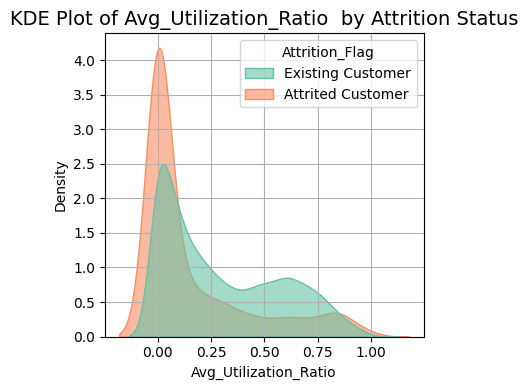

In [ ]:
plt.figure(figsize=(4, 4))
sns.kdeplot(data=bank, x='Avg_Utilization_Ratio', hue='Attrition_Flag', fill=True, common_norm=False, palette='Set2', alpha=0.6)
plt.title('KDE Plot of Avg_Utilization_Ratio  by Attrition Status', fontsize=14)
plt.xlabel('Avg_Utilization_Ratio')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

**Analysis:**

1.Attrited customers have a sharper peak near zero in Avg_Utilization_Ratio, indicating lower credit utilization.

2.Existing customers show a broader distribution, with higher density in mid-to-high utilization ranges.

3.Very low utilization might suggest disinterest or under-engagement with credit products.

4.Higher utilization is more associated with retained (existing) customers, possibly indicating deeper financial involvement.

**Recommendation:**
Identify and target low-utilization customers with credit education, usage incentives, or tailored product offers to encourage engagement and reduce attrition risk.







